In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
from tensorflow.keras.utils import image_dataset_from_directory

In [9]:
old_data = '../data/Driver Drowsiness Dataset (DDD)'
split_data = '../data/split_data'
splitfolders.ratio(old_data, output=split_data, seed=42, ratio=(0.8, 0.125, 0.075), group_prefix=None)

In [10]:
BATCH_SIZE = 128
IMG_SIZE = (128, 128)

train_dataset = image_dataset_from_directory(
      '../data/split_data/train',
      shuffle=True,
      batch_size=BATCH_SIZE,
      image_size=IMG_SIZE,
      seed=42
  )

validation_dataset = image_dataset_from_directory(
    '../data/split_data/val',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42
)

test_dataset = image_dataset_from_directory(
    '../data/split_data/test',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42
)

Found 33434 files belonging to 2 classes.
Found 5223 files belonging to 2 classes.
Found 3136 files belonging to 2 classes.


2026-07-11 15:24:04.909924: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


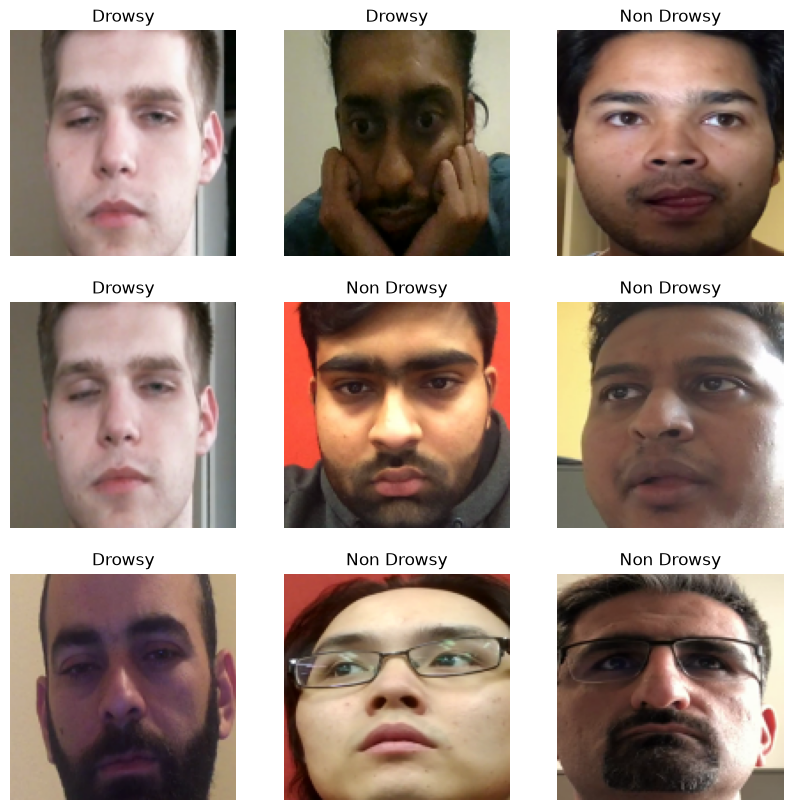

In [14]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [17]:
model = Sequential([
    Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3), kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(16, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dense(16, activation='relu', 
          kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])


In [18]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,801 (26.57 KB)

 Trainable params: 6,689 (26.13 KB)

 Non-trainable params: 112 (448.00 B)

In [19]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.5509 - loss: 1.2181 - val_accuracy: 0.6567 - val_loss: 1.0909
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7225 - loss: 0.9852 - val_accuracy: 0.8018 - val_loss: 0.8828
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.8078 - loss: 0.8428 - val_accuracy: 0.8671 - val_loss: 0.7579
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8564 - loss: 0.7392 - val_accuracy: 0.9127 - val_loss: 0.6624
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8899 - loss: 0.6503 - val_accuracy: 0.9246 - val_loss: 0.5749
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9223 - loss: 0.5640 - val_accuracy: 0.9491 - val_loss: 0.5048
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9449 - loss: 0.4848 - val_accuracy: 0.9759 - val_loss: 0.4157
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9582 - loss: 0.4254 - 

In [20]:
model.evaluate(test_dataset)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9928 - loss: 0.3008


[0.28933185338974, 0.9891581535339355]

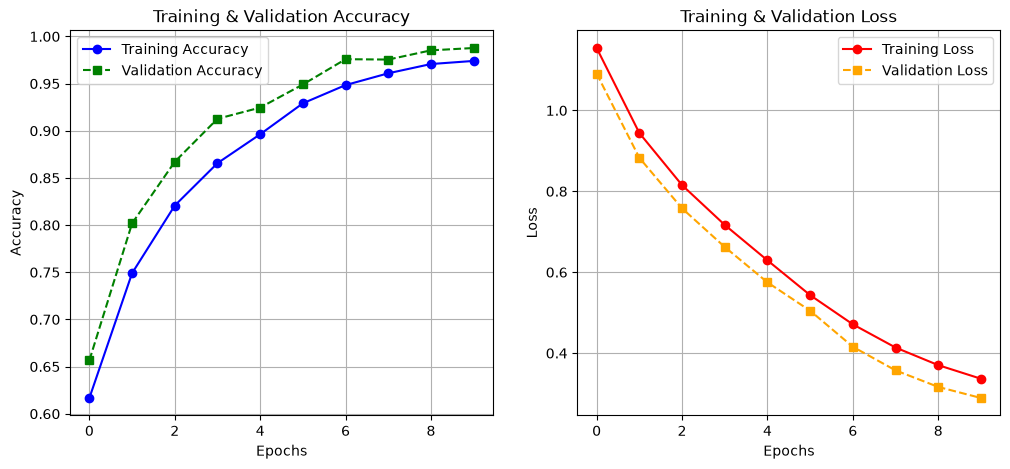

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", color="blue", marker="o", linestyle="-")
plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="green", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", color="red", marker="o", linestyle="-")
plt.plot(epochs_range, val_loss, label="Validation Loss", color="orange", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)

plt.show()

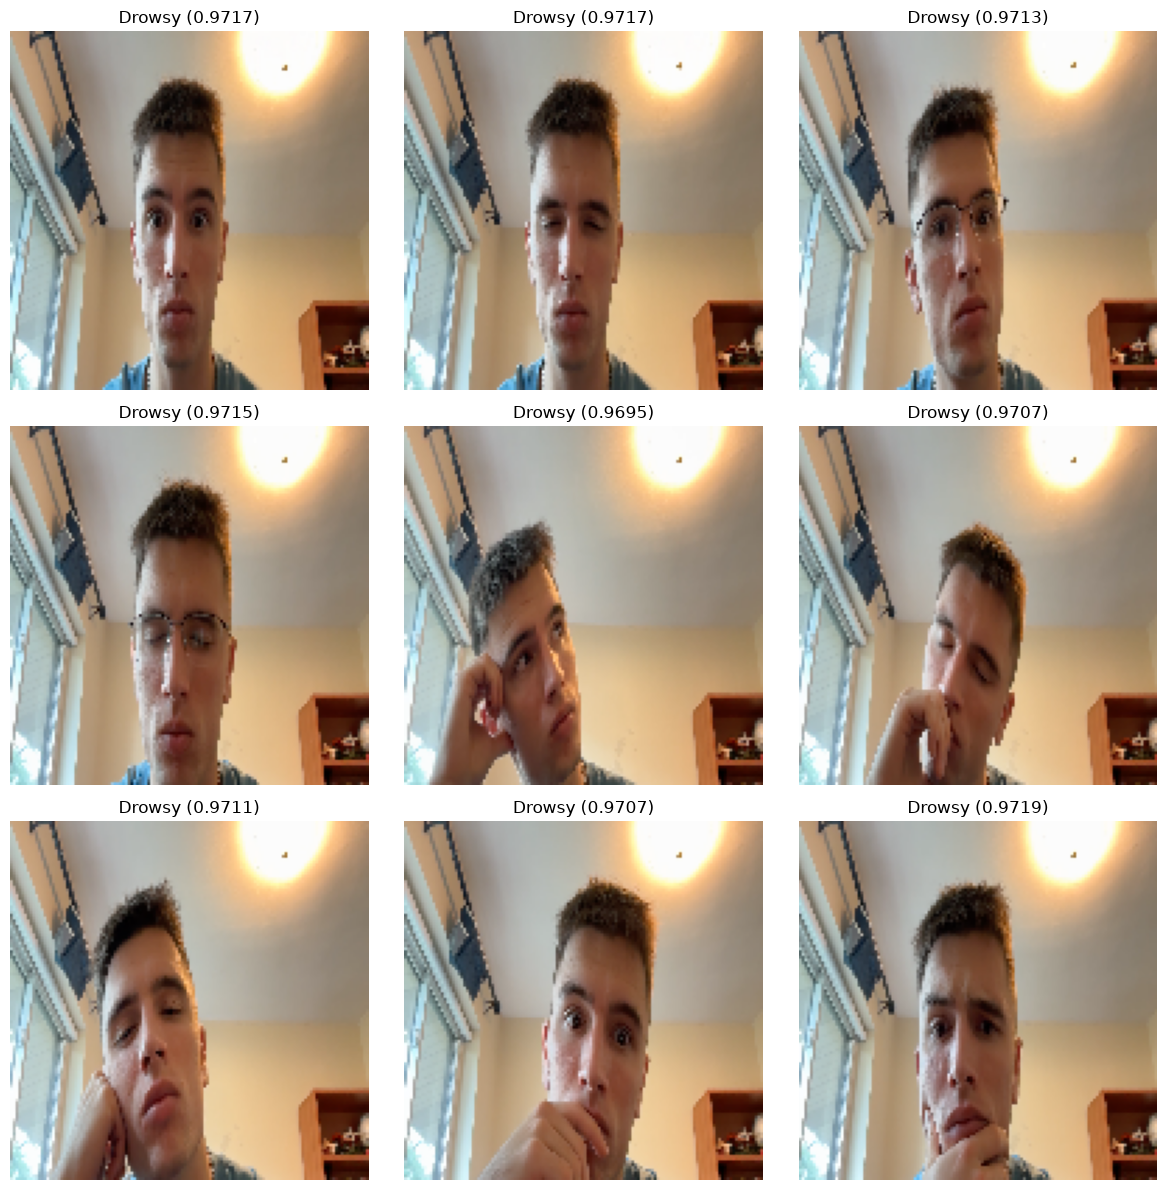

In [22]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

selfie_dir = '../data/selfies'
selfie_paths = sorted([
    os.path.join(selfie_dir, f)
    for f in os.listdir(selfie_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

class_names = test_dataset.class_names  # e.g. ['Drowsy', 'Non Drowsy']

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    return img, np.expand_dims(img_array, axis=0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, path in enumerate(selfie_paths[:9]):
    img, img_array = preprocess_image(path)
    pred = model.predict(img_array, verbose=0)[0][0]
    class_idx = 1 if pred > 0.5 else 0
    label = class_names[class_idx]
    confidence = pred if class_idx == 1 else 1 - pred

    axes[i].imshow(img)
    axes[i].set_title(f"{label} ({confidence:.4f})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [23]:
num_images = 15

test_dataset.reset()
images, true_labels = next(test_dataset)

images = images[:num_images]
true_labels = true_labels[:num_images]

predictions = model.predict(images)

class_indices = test_dataset.class_indices
class_names = {v: k for k, v in class_indices.items()}

rows = (num_images + 4) // 5
cols = min(num_images, 5)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if num_images > 1 else [axes]

for i in range(num_images):
    img = images[i]
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_label} ({confidence:.4f})")
    axes[i].axis('off')


for i in range(num_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Predictions for displayed images:")
for i in range(num_images):
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    print(f"Image {i+1}: Predicted Class: {pred_label}, Confidence: {confidence:.4f}")

AttributeError: '_PrefetchDataset' object has no attribute 'reset'